In [1]:
import os, warnings, logging, json, shutil
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
 
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers, models, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from collections import defaultdict, deque
 
print("TF:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("CPU threads:", tf.config.threading.get_inter_op_parallelism_threads())
 

TF: 2.18.0
Keras: 3.12.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU threads: 0


In [2]:
IMG_SIZE   = 112
SEQ_LEN    = 8       
BATCH_SIZE = 32
EPOCHS_S1  = 30      
EPOCHS_S2  = 20      
LR_S1      = 1e-3
LR_S2      = 1e-5
 
DATASET_BASE = '/Users/stevennn/Downloads/DAiSEE/DataSet'
LABELS_BASE  = '/Users/stevennn/Downloads/DAiSEE/Labels'
 
TASK_CONFIG = {
    'boredom_lbl':     4,
    'engagement_lbl':  4,
    'confusion_lbl':   3,
    'frustration_lbl': 3,
}
 
LABEL_MAPS = {
    'boredom':     {0: 'Not Bored',      1: 'Slightly Bored',
                    2: 'Moderately Bored', 3: 'Very Bored'},
    'engagement':  {0: 'Not Engaged',    1: 'Slightly Engaged',
                    2: 'Moderately Engaged', 3: 'Highly Engaged'},
    'confusion':   {0: 'Not Confused',   1: 'Slightly Confused', 2: 'Confused'},
    'frustration': {0: 'Not Frustrated', 1: 'Slightly Frustrated', 2: 'Frustrated'},
}
 
ENGAGEMENT_COLOR = {0: '#ef4444', 1: '#f97316', 2: '#eab308', 3: '#22c55e'}
 
LABEL_NAMES = {
    'boredom_lbl':     ['None', 'Low', 'Mid', 'High'],
    'engagement_lbl':  ['None', 'Low', 'Mid', 'High'],
    'confusion_lbl':   ['None', 'Low', 'Mid/High'],
    'frustration_lbl': ['None', 'Low', 'Mid/High'],
}
 
print("Config loaded.")

Config loaded.


In [3]:
train_df = pd.read_csv(f'{LABELS_BASE}/TrainLabels.csv')
val_df   = pd.read_csv(f'{LABELS_BASE}/ValidationLabels.csv')
test_df  = pd.read_csv(f'{LABELS_BASE}/TestLabels.csv')
 
for df in [train_df, val_df, test_df]:
    df.columns = df.columns.str.strip()
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
def show_distribution(df, name):
    print(f"\n{name} distribution:")
    for col in ['Boredom', 'Engagement', 'Confusion', 'Frustration']:
        vc  = df[col].value_counts().sort_index()
        row = "  " + col.ljust(12)
        for cls in [0, 1, 2, 3]:
            cnt  = vc.get(cls, 0)
            row += f"  [{cls}]:{cnt:4d}({cnt / len(df) * 100:4.1f}%)"
        print(row)
 
show_distribution(train_df, 'Train')
show_distribution(val_df,   'Val')

Train: 5358 | Val: 1429 | Test: 1784

Train distribution:
  Boredom       [0]:2433(45.4%)  [1]:1696(31.7%)  [2]:1073(20.0%)  [3]: 156( 2.9%)
  Engagement    [0]:  34( 0.6%)  [1]: 213( 4.0%)  [2]:2617(48.8%)  [3]:2494(46.5%)
  Confusion     [0]:3616(67.5%)  [1]:1245(23.2%)  [2]: 431( 8.0%)  [3]:  66( 1.2%)
  Frustration   [0]:4183(78.1%)  [1]: 941(17.6%)  [2]: 191( 3.6%)  [3]:  43( 0.8%)

Val distribution:
  Boredom       [0]: 446(31.2%)  [1]: 376(26.3%)  [2]: 475(33.2%)  [3]: 132( 9.2%)
  Engagement    [0]:  23( 1.6%)  [1]: 143(10.0%)  [2]: 813(56.9%)  [3]: 450(31.5%)
  Confusion     [0]: 942(65.9%)  [1]: 322(22.5%)  [2]: 153(10.7%)  [3]:  12( 0.8%)
  Frustration   [0]:1058(74.0%)  [1]: 271(19.0%)  [2]:  81( 5.7%)  [3]:  19( 1.3%)


In [5]:
def encode_labels(df):
    df = df.copy()
    df['boredom_lbl']     = df['Boredom'].clip(0, 3).astype(int)
    df['engagement_lbl']  = df['Engagement'].clip(0, 3).astype(int)
    df['confusion_lbl']   = df['Confusion'].clip(0, 2).astype(int)    
    df['frustration_lbl'] = df['Frustration'].clip(0, 2).astype(int)  
    return df
 
train_df = encode_labels(train_df)
val_df   = encode_labels(val_df)
test_df  = encode_labels(test_df)
 
print("After merging rare classes:")
for col in ['confusion_lbl', 'frustration_lbl']:
    print(f"  {col}: {dict(train_df[col].value_counts().sort_index())}")
 

After merging rare classes:
  confusion_lbl: {0: 3616, 1: 1245, 2: 497}
  frustration_lbl: {0: 4183, 1: 941, 2: 234}


In [7]:
def get_weights(df, col):
    y       = df[col].values
    classes = np.unique(y)
    w       = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes.tolist(), w.tolist()))
 
class_weights = {col: get_weights(train_df, col) for col in TASK_CONFIG}
 
print("Class weights:")
for col, w in class_weights.items():
    print(f"  {col}: { {k: round(v, 3) for k, v in w.items()} }")
 
 
def make_sample_weight(y_batch, cw_dict):

    n = len(next(iter(y_batch.values())))
    w = np.ones(n, dtype=np.float32)
    for col, cw in cw_dict.items():
        labels = y_batch[col]
        task_w = np.array([cw.get(int(l), 1.0) for l in labels], dtype=np.float32)
        w     += task_w
    w /= len(cw_dict)
    w  = w / (w.mean() + 1e-8)
    return w

Class weights:
  boredom_lbl: {0: 0.551, 1: 0.79, 2: 1.248, 3: 8.587}
  engagement_lbl: {0: 39.397, 1: 6.289, 2: 0.512, 3: 0.537}
  confusion_lbl: {0: 0.494, 1: 1.435, 2: 3.594}
  frustration_lbl: {0: 0.427, 1: 1.898, 2: 7.632}


In [8]:
_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
_face_cascade = cv2.CascadeClassifier(_cascade_path) \
                if os.path.exists(_cascade_path) else None
 
EMOTION_BOX_COLORS = {
    'Highly Engaged':      (34,  197, 94),
    'Moderately Engaged':  (34,  197, 94),
    'Slightly Engaged':    (234, 179,  8),
    'Not Engaged':         (239,  68, 68),
    'Slightly Bored':      (234, 179,  8),
    'Moderately Bored':    (249, 115, 22),
    'Very Bored':          (239,  68, 68),
    'Slightly Confused':   (234, 179,  8),
    'Confused':            (239,  68, 68),
    'Slightly Frustrated': (249, 115, 22),
    'Frustrated':          (239,  68, 68),
    'default':             (255, 255, 255),
}
 
 
def detect_face(frame, margin=0.25):
    if _face_cascade is None or _face_cascade.empty():
        return frame, None
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = _face_cascade.detectMultiScale(gray, 1.1, 4, minSize=(30, 30))
    if len(faces) == 0:
        return frame, None
    fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
    H, W = frame.shape[:2]
    pw, ph = int(fw * margin), int(fh * margin)
    x1 = max(0, fx - pw);  y1 = max(0, fy - ph)
    x2 = min(W, fx+fw+pw); y2 = min(H, fy+fh+ph)
    cropped = frame[y1:y2, x1:x2]
    bbox    = dict(x1=x1, y1=y1, x2=x2, y2=y2,
                   face_x=fx, face_y=fy, face_w=fw, face_h=fh)
    return (cropped if cropped.size > 0 else frame), bbox
 
 
def crop_face(frame, margin=0.25):
    cropped, _ = detect_face(frame, margin)
    return cropped
 
 
def draw_overlay(frame, bbox, prediction, show_all=True):
    out = frame.copy()
    if bbox is None:
        cv2.putText(out, 'No face detected', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100, 100, 100), 2)
        return out
 
    x1, y1, x2, y2 = bbox['x1'], bbox['y1'], bbox['x2'], bbox['y2']
    eng_label = prediction['engagement']['label']
    color     = EMOTION_BOX_COLORS.get(eng_label, EMOTION_BOX_COLORS['default'])
 
    cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
    corner = 18
    for cx, cy, dx, dy in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
        cv2.line(out, (cx, cy), (cx + dx*corner, cy),             color, 3)
        cv2.line(out, (cx, cy), (cx,              cy + dy*corner), color, 3)
 
    dominant   = prediction['dominant']
    conf       = prediction['engagement']['confidence']
    label_text = f"{dominant}  {conf*100:.0f}%"
    font       = cv2.FONT_HERSHEY_SIMPLEX
    fs, ft     = 0.55, 1
    (tw, th), baseline = cv2.getTextSize(label_text, font, fs, ft)
    pad = 5
    pill_x1 = x1;          pill_y1 = max(0, y1 - th - 2*pad - baseline)
    pill_x2 = x1+tw+2*pad; pill_y2 = max(th+2*pad, y1)
    overlay = out.copy()
    cv2.rectangle(overlay, (pill_x1, pill_y1), (pill_x2, pill_y2), color, -1)
    cv2.addWeighted(overlay, 0.75, out, 0.25, 0, out)
    cv2.putText(out, label_text, (pill_x1+pad, pill_y2-pad-baseline),
                font, fs, (0,0,0), ft, cv2.LINE_AA)
 
    if prediction.get('alert'):
        alert_text = f"!  {prediction['alert']}"
        (aw, ah), _ = cv2.getTextSize(alert_text, font, 0.5, 1)
        ax1, ay1 = x1, y2; ax2, ay2 = x1+aw+2*pad, y2+ah+2*pad
        overlay2 = out.copy()
        cv2.rectangle(overlay2, (ax1, ay1), (ax2, ay2), (0, 0, 200), -1)
        cv2.addWeighted(overlay2, 0.75, out, 0.25, 0, out)
        cv2.putText(out, alert_text, (ax1+pad, ay2-pad),
                    font, 0.5, (255,255,255), 1, cv2.LINE_AA)
 
    if show_all:
        panel_x = min(x2+10, out.shape[1]-160); panel_y = y1; row_h = 26
        for i, emo in enumerate(['engagement','boredom','confusion','frustration']):
            info    = prediction[emo]
            e_color = EMOTION_BOX_COLORS.get(info['label'], EMOTION_BOX_COLORS['default'])
            py      = panel_y + i * row_h
            tag     = emo.capitalize()[:3].upper()
            text    = f"{tag}  {info['label'].split()[-1]}  {info['confidence']*100:.0f}%"
            overlay3 = out.copy()
            cv2.rectangle(overlay3, (panel_x, py),
                          (panel_x+155, py+row_h-2), (30,30,30), -1)
            cv2.addWeighted(overlay3, 0.6, out, 0.4, 0, out)
            cv2.circle(out, (panel_x+8, py+row_h//2), 5, e_color, -1)
            cv2.putText(out, text, (panel_x+18, py+row_h-8),
                        font, 0.42, (220,220,220), 1, cv2.LINE_AA)
    return out
 
print("Face utilities ready.")
 
 

Face utilities ready.


In [9]:
class FocalLoss(keras.losses.Loss):
    
    def __init__(self, gamma=3.0, alpha=0.5, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
 
    def call(self, y_true, y_pred):
        y_true = tf.cast(
            tf.squeeze(y_true, axis=-1) if y_true.shape[-1] == 1 else y_true,
            tf.int32)
        n      = tf.shape(y_pred)[-1]
        y_oh   = tf.one_hot(y_true, n)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce     = -y_oh * tf.math.log(y_pred)
        p_t    = tf.reduce_sum(y_oh * y_pred, axis=-1, keepdims=True)
        focal  = self.alpha * tf.pow(1 - p_t, self.gamma) * ce
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg
 
 
def weighted_categorical_crossentropy(class_weight_dict, n_classes):
 
    weights        = np.zeros(n_classes, dtype=np.float32)
    for cls, w in class_weight_dict.items():
        weights[cls] = w
    weights_tensor = tf.constant(weights, dtype=tf.float32)
 
    def loss_fn(y_true, y_pred):
        y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        y_oh     = tf.one_hot(y_true, n_classes)
        sample_w = tf.reduce_sum(y_oh * weights_tensor, axis=-1)
        ce       = -tf.reduce_sum(y_oh * tf.math.log(y_pred), axis=-1)
        return tf.reduce_mean(sample_w * ce)
 
    loss_fn.__name__ = 'weighted_ce'
    return loss_fn
 
 
loss_fns = {
    'boredom_lbl':     FocalLoss(gamma=3.0, alpha=0.5),
    'engagement_lbl':  FocalLoss(gamma=3.0, alpha=0.5),
    'confusion_lbl':   weighted_categorical_crossentropy(
                           class_weights['confusion_lbl'], n_classes=3),
    'frustration_lbl': weighted_categorical_crossentropy(
                           class_weights['frustration_lbl'], n_classes=3),
}
 
print("Loss functions:")
for col, fn in loss_fns.items():
    name = fn.__class__.__name__ if hasattr(fn, '__class__') else fn.__name__
    print(f"  {col}: {name}")

Loss functions:
  boredom_lbl: FocalLoss
  engagement_lbl: FocalLoss
  confusion_lbl: function
  frustration_lbl: function


I0000 00:00:1774170706.538794 37753680 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774170706.538910 37753680 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
class BalancedSampler:

    def __init__(self, labels_array, task_col, samples_per_class=8):
        self.spc     = samples_per_class
        self.buckets = defaultdict(list)
        for i, val in enumerate(labels_array):
            self.buckets[int(val)].append(i)
        print(f"  BalancedSampler on '{task_col}':")
        for cls, idxs in sorted(self.buckets.items()):
            print(f"    class {cls}: {len(idxs)} samples")
 
    def get_epoch_indices(self, n_batches):
        all_batches = []
        for _ in range(n_batches):
            batch_idx = []
            for cls, indices in self.buckets.items():
                chosen = np.random.choice(indices, size=self.spc, replace=True)
                batch_idx.extend(chosen.tolist())
            np.random.shuffle(batch_idx)
            all_batches.append(batch_idx)
        return all_batches
 

In [11]:
class DAiSEEGenerator(keras.utils.Sequence):
    def __init__(self, df, video_dir, batch_size=32, num_frames=8,
                 augment=False, use_sample_weights=False, balanced=False):
        self.df                 = df.reset_index(drop=True)
        self.batch_size         = batch_size
        self.num_frames         = num_frames
        self.augment            = augment
        self.use_sample_weights = use_sample_weights
        self.balanced           = balanced
        self.cache              = {}
        self.corrupted          = set()
        self._samples           = []  
        self._epoch_indices     = []
        self._index(video_dir)
        self._build()
 
        if self.balanced and len(self._samples) > 0:
          
            sample_boredom = np.array([s[2]['boredom_lbl'] for s in self._samples])
            spc = max(2, batch_size // len(TASK_CONFIG) // 2)
            self.sampler = BalancedSampler(sample_boredom, 'boredom_lbl',
                                           samples_per_class=spc)
 
        self.on_epoch_end()
 
    def _index(self, video_dir):
        for root, _, files in os.walk(video_dir):
            for f in files:
                if f.endswith(('.avi', '.mp4')):
                    self.cache[f] = os.path.join(root, f)
        print(f"  Indexed {len(self.cache)} videos")
 
    def _build(self):
        label_cols = list(TASK_CONFIG.keys())
        for i, row in self.df.iterrows():
            path = self.cache.get(row['ClipID'])
            if not path or not os.path.exists(path):
                continue
            labels = {col: int(row[col]) for col in label_cols}
            self._samples.append((i, path, labels))
        print(f"  Valid clips: {len(self._samples)}")
 
    def __len__(self):
        return len(self._epoch_indices)
 
    def on_epoch_end(self):
        n_batches = int(np.ceil(len(self._samples) / self.batch_size))
        if self.balanced:
            self._epoch_indices = self.sampler.get_epoch_indices(n_batches)
        else:
            idx = np.random.permutation(len(self._samples)) if self.augment \
                  else np.arange(len(self._samples))
            # Pad to full batches
            self._epoch_indices = [
                idx[i * self.batch_size:(i+1) * self.batch_size].tolist()
                for i in range(n_batches)
            ]
 
    def __getitem__(self, idx):
        batch_indices = self._epoch_indices[idx]
        X = []
        y = {col: [] for col in TASK_CONFIG}
 
        for si in batch_indices:
            if si >= len(self._samples):
                continue
            _, path, labels = self._samples[si]
            frames = self._read_sequence(path)
            if frames is None:
                continue
            X.append(frames)
            for col in TASK_CONFIG:
                y[col].append(labels[col])
 
        if not X:
            X = np.zeros((1, self.num_frames, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            for col in TASK_CONFIG:
                y[col] = [0]
        else:
            X = np.array(X, dtype=np.uint8)
 
        y = {col: np.array(v, dtype=np.int32) for col, v in y.items()}
 
        if self.use_sample_weights:
            return X, y, make_sample_weight(y, class_weights)
        return X, y
 
    def _read_sequence(self, path):
      
        if path in self.corrupted:
            return None
        try:
            cap   = cv2.VideoCapture(path)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total < 1:
                cap.release(); self.corrupted.add(path); return None
 
            indices = np.linspace(0, total - 1, self.num_frames, dtype=int)
            frames  = []
            for fi in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
                ret, frame = cap.read()
                if not ret or frame is None:
                    cap.release(); return None
                face = crop_face(frame)
                face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
                if self.augment:
                    face = self._aug(face)
                frames.append(face)
            cap.release()
            return np.stack(frames)
        except Exception:
            self.corrupted.add(path); return None
 
    def _aug(self, f):
     
        f = f.astype(np.float32)
        if np.random.random() > 0.5:
            f = np.fliplr(f)
        # Brightness
        f = np.clip(f * np.random.uniform(0.7, 1.3), 0, 255)
        # Contrast
        c = np.random.uniform(0.8, 1.2)
        f = np.clip((f - f.mean()) * c + f.mean(), 0, 255)
        # Rotation ±12 degrees
        angle = np.random.uniform(-12, 12)
        M     = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
        f     = cv2.warpAffine(f, M, (IMG_SIZE, IMG_SIZE))
        # Random zoom
        if np.random.random() > 0.5:
            z   = np.random.uniform(0.85, 1.0)
            sz  = int(IMG_SIZE * z); off = (IMG_SIZE - sz) // 2
            f   = f[off:off+sz, off:off+sz]
            f   = cv2.resize(f, (IMG_SIZE, IMG_SIZE))
        return f.astype(np.uint8)
 
 
print("\n=== Building generators ===")
print("\nTrain:")
train_gen = DAiSEEGenerator(
    train_df, f'{DATASET_BASE}/Train',
    batch_size=BATCH_SIZE, num_frames=SEQ_LEN,
    augment=True, use_sample_weights=True, balanced=True
)
 
print("\nVal:")
val_gen = DAiSEEGenerator(
    val_df, f'{DATASET_BASE}/Validation',
    batch_size=BATCH_SIZE, num_frames=SEQ_LEN,
    augment=False, use_sample_weights=False, balanced=False
)
 

print("\nClass distribution sanity check (batch 0):")
result = train_gen[0]
X_check, y_check = result[0], result[1]
for col in TASK_CONFIG:
    vals, counts = np.unique(y_check[col], return_counts=True)
    print(f"  {col}: { dict(zip(vals.tolist(), counts.tolist())) }")
 


=== Building generators ===

Train:
  Indexed 5482 videos
  Valid clips: 5358
  BalancedSampler on 'boredom_lbl':
    class 0: 2433 samples
    class 1: 1696 samples
    class 2: 1073 samples
    class 3: 156 samples

Val:
  Indexed 1720 videos
  Valid clips: 1429

Class distribution sanity check (batch 0):
  boredom_lbl: {0: 4, 1: 4, 2: 4, 3: 4}
  engagement_lbl: {1: 2, 2: 9, 3: 5}
  confusion_lbl: {0: 9, 1: 4, 2: 3}
  frustration_lbl: {0: 11, 1: 3, 2: 2}


In [12]:
def build_model():
    
    frame_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='frame')
 
    backbone = tf.keras.applications.EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False
 
    x = backbone(frame_input, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
 
    frame_encoder = models.Model(inputs=frame_input, outputs=x, name='frame_encoder')
 
    # Sequence model
    seq_input = layers.Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3), name='clip')
    features  = layers.TimeDistributed(frame_encoder, name='td_encoder')(seq_input)
 
    # Temporal layers
    x = layers.GRU(128, return_sequences=True, dropout=0.3,
                   recurrent_dropout=0.1)(features)
    x = layers.GRU(64, return_sequences=False, dropout=0.3)(x)
 
    # Shared trunk
    shared = layers.Dense(256)(x)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Activation('relu')(shared)
    shared = layers.Dropout(0.4)(shared)
 

    head_sizes = {
        'boredom_lbl':     128,
        'engagement_lbl':  128,
        'confusion_lbl':   256,  
        'frustration_lbl': 256,  
    }
 
    outputs = {}
    for col, n_cls in TASK_CONFIG.items():
        h = layers.Dense(
            head_sizes[col], activation='relu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'{col}_h1'
        )(shared)
        h = layers.BatchNormalization(name=f'{col}_bn')(h)
        h = layers.Dropout(0.3, name=f'{col}_drop1')(h)
        h = layers.Dense(
            64, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'{col}_h2'
        )(h)
        h = layers.Dropout(0.2, name=f'{col}_drop2')(h)
        outputs[col] = layers.Dense(
            n_cls, activation='softmax',
    
            bias_initializer=tf.keras.initializers.Constant(
                np.log(np.ones(n_cls, dtype=np.float32) / n_cls)
            ),
            name=col
        )(h)
 
    model = models.Model(inputs=seq_input, outputs=outputs, name='DAiSEE_v3')
    return model, backbone, frame_encoder
 
 
model, backbone, frame_encoder = build_model()
model.summary()
print(f"\nTotal params: {model.count_params():,}")
 

Model: "DAiSEE_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ clip (InputLayer)   │ (None, 8, 112,    │          0 │ -                 │
│                     │ 112, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_encoder          │ (None, 8, 256)    │  4,377,507 │ clip[0][0]        │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 8, 128)    │    148,224 │ td_encoder[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     37,248 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     16,640 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boredom_lbl_h1      │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ confusion_lbl_h1    │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement_lbl_h1   │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frustration_lbl_h1  │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boredom_lbl_bn      │ (None, 128)       │        512 │ boredom_lbl_h1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ confusion_lbl_bn    │ (None, 256)       │      1,024 │ confusion_lbl_h1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement_lbl_bn   │ (None, 128)       │        512 │ engagement_lbl_h… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frustration_lbl_bn  │ (None, 256)       │      1,024 │ frustration_lbl_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boredom_lbl_drop1   │ (None, 128)       │          0 │ boredom_lbl_bn[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ confusion_lbl_drop1 │ (None, 256)       │          0 │ confusion_lbl_bn… │
│ (Dropout)           │                   │            │                 

 Total params: 4,831,409 (18.43 MB)

 Trainable params: 779,790 (2.97 MB)

 Non-trainable params: 4,051,619 (15.46 MB)


Total params: 4,831,409


In [13]:
def get_callbacks(stage):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, 
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.4,
            patience=3, min_lr=1e-7, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f'daisee_v3_s{stage}.keras',
            monitor='val_loss', save_best_only=True, verbose=1
        ),
    ]
 

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(LR_S1),
    loss=loss_fns,
    loss_weights={
        'boredom_lbl':     1.2,  
        'engagement_lbl':  1.0,
        'confusion_lbl':   1.5,  
        'frustration_lbl': 1.5,  
    },
    metrics={col: ['accuracy'] for col in TASK_CONFIG}
)
 
print("=" * 60)
print("STAGE 1 — Frozen EfficientNetB0, balanced batches")
print("=" * 60)
 
h1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_S1,
    callbacks=get_callbacks(1),
    verbose=1
   
)


STAGE 1 — Frozen EfficientNetB0, balanced batches
Epoch 1/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - boredom_lbl_accuracy: 0.2404 - boredom_lbl_loss: 0.9147 - confusion_lbl_accuracy: 0.3304 - confusion_lbl_loss: 2.0516 - engagement_lbl_accuracy: 0.3074 - engagement_lbl_loss: 0.7909 - frustration_lbl_accuracy: 0.3416 - frustration_lbl_loss: 2.7589 - loss: 9.2272
Epoch 1: val_loss improved from None to 4.71053, saving model to daisee_v3_s1.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - boredom_lbl_accuracy: 0.2552 - boredom_lbl_loss: 0.7529 - confusion_lbl_accuracy: 0.3333 - confusion_lbl_loss: 1.9040 - engagement_lbl_accuracy: 0.3259 - engagement_lbl_loss: 0.6207 - frustration_lbl_accuracy: 0.3248 - frustration_lbl_loss: 2.5983 - loss: 8.4011 - val_boredom_lbl_accuracy: 0.2757 - val_boredom_lbl_loss: 0.2842 - val_confusion_lbl_accuracy: 0.1260 - val_confusion_lbl_loss: 1.1910 - val_engagement_lbl_accuracy: 0.5689 - val_engagement_lbl_loss: 0.1944 - val_frustration_lbl_accuracy: 0.0

In [15]:
backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False
 
trainable = sum(1 for l in backbone.layers if l.trainable)
print(f"Trainable backbone layers: {trainable} / {len(backbone.layers)}")
 
model.compile(
    optimizer=keras.optimizers.Adam(LR_S2),
    loss=loss_fns,
    loss_weights={
        'boredom_lbl':     1.2,
        'engagement_lbl':  1.0,
        'confusion_lbl':   1.5,
        'frustration_lbl': 1.5,
    },
    metrics={col: ['accuracy'] for col in TASK_CONFIG}
)
 
print("=" * 60)
print("STAGE 2 — Fine-tune top 80 layers")
print("=" * 60)
 
h2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_S2,
    callbacks=get_callbacks(2),
    verbose=1
)

Trainable backbone layers: 80 / 238
STAGE 2 — Fine-tune top 80 layers
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - boredom_lbl_accuracy: 0.2856 - boredom_lbl_loss: 0.2927 - confusion_lbl_accuracy: 0.4012 - confusion_lbl_loss: 1.1492 - engagement_lbl_accuracy: 0.5324 - engagement_lbl_loss: 0.1882 - frustration_lbl_accuracy: 0.3026 - frustration_lbl_loss: 1.2793 - loss: 4.3030
Epoch 1: val_loss improved from None to 4.42785, saving model to daisee_v3_s2.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 510s 3s/step - boredom_lbl_accuracy: 0.2839 - boredom_lbl_loss: 0.2939 - confusion_lbl_accuracy: 0.3984 - confusion_lbl_loss: 1.1513 - engagement_lbl_accuracy: 0.5298 - engagement_lbl_loss: 0.1831 - frustration_lbl_accuracy: 0.2995 - frustration_lbl_loss: 1.2778 - loss: 4.3003 - val_boredom_lbl_accuracy: 0.2792 - val_boredom_lbl_loss: 0.2851 - val_confusion_lbl_accuracy: 0.3520 - val_confusion_lbl_loss: 1.1913 - val_engagement_lbl_accuracy: 0.5500 - val_engagement_lbl_loss: 0.1626 - val_frustrati

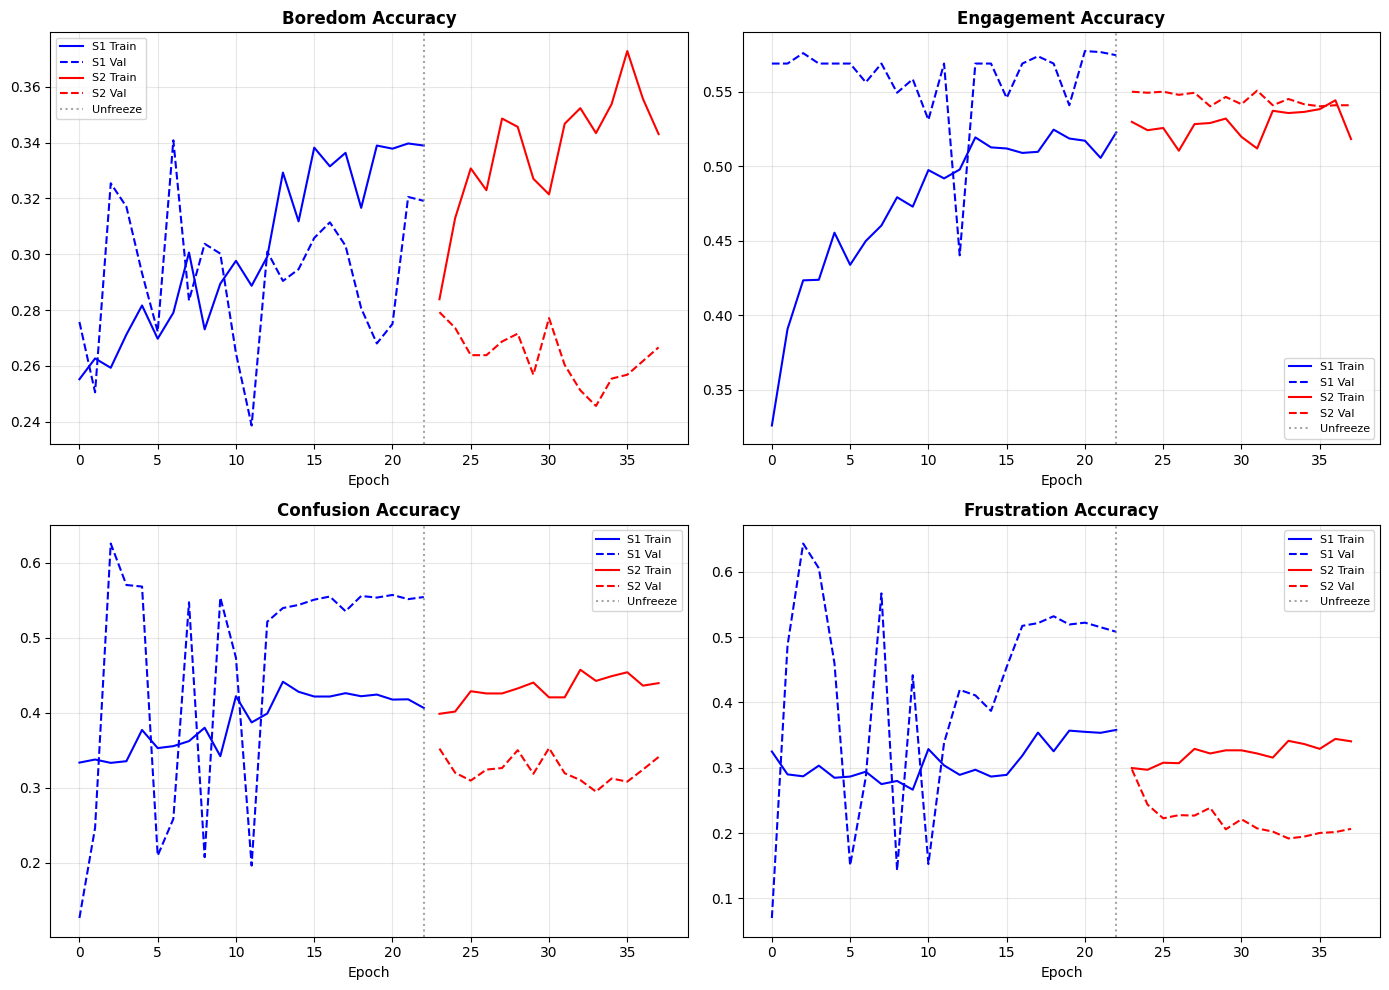

In [16]:
def plot_training(h1, h2):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, col in zip(axes.flatten(), TASK_CONFIG):
        key = f'{col}_accuracy'
        s1t = h1.history.get(key, [])
        s1v = h1.history.get(f'val_{key}', [])
        s2t = h2.history.get(key, [])
        s2v = h2.history.get(f'val_{key}', [])
        off = len(s1t)
        ax.plot(s1t,                             'b-',  label='S1 Train')
        ax.plot(s1v,                             'b--', label='S1 Val')
        ax.plot(range(off, off+len(s2t)), s2t,   'r-',  label='S2 Train')
        ax.plot(range(off, off+len(s2v)), s2v,   'r--', label='S2 Val')
        ax.axvline(x=off-1, color='gray', linestyle=':', alpha=0.7, label='Unfreeze')
        ax.set_title(col.replace('_lbl', '').capitalize() + ' Accuracy',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves_v3.png', dpi=150)
    plt.show()
 
plot_training(h1, h2)

In [18]:
def collect_probs(model, gen):

    all_probs = {col: [] for col in TASK_CONFIG}
    all_true  = {col: [] for col in TASK_CONFIG}
 
    for i in range(len(gen)):
        result = gen[i]
        X, y_true = result[0], result[1]
        y_pred = model.predict(X, verbose=0)
        for col in TASK_CONFIG:
            all_probs[col].extend(y_pred[col].tolist())
            all_true[col].extend(y_true[col].tolist())
 
    return (
        {col: np.array(v) for col, v in all_probs.items()},
        {col: np.array(v) for col, v in all_true.items()},
    )
 
print("Collecting validation probabilities...")
val_probs, val_true = collect_probs(model, val_gen)
print("Done.")

Done.


In [19]:
def calibrate_thresholds(probs, true_labels):

    thresholds = {}
 
    for col in TASK_CONFIG:
        n_cls = TASK_CONFIG[col]
        p     = probs[col]        # (N, n_cls)
        y     = true_labels[col]  # (N,)
        col_thresholds = np.full(n_cls, 0.5)
 
        print(f"\n{col}:")
        for cls in range(n_cls):
            best_t  = 0.5
            best_f1 = 0.0
            binary_true = (y == cls).astype(int)
 
            for t in np.arange(0.05, 0.90, 0.05):
                pred_cls = (p[:, cls] >= t).astype(int)
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    f = f1_score(binary_true, pred_cls, zero_division=0)
                if f > best_f1:
                    best_f1 = f; best_t = t
 
            col_thresholds[cls] = best_t
            label_name = LABEL_NAMES[col][cls] if cls < len(LABEL_NAMES[col]) else str(cls)
            print(f"  class {cls} ({label_name}): "
                  f"threshold={best_t:.2f}  binary-F1={best_f1:.3f}")
 
        thresholds[col] = col_thresholds
 
    return thresholds
 
 
print("Calibrating thresholds...")
thresholds = calibrate_thresholds(val_probs, val_true)
 
# Save so Cloud Run deployment can load them without rerunning calibration
thresholds_serializable = {k: v.tolist() for k, v in thresholds.items()}
with open('thresholds_v3.json', 'w') as f:
    json.dump(thresholds_serializable, f, indent=2)
print("\nThresholds saved to thresholds_v3.json")

Calibrating thresholds...

boredom_lbl:
  class 0 (None): threshold=0.20  binary-F1=0.497
  class 1 (Low): threshold=0.25  binary-F1=0.425
  class 2 (Mid): threshold=0.25  binary-F1=0.502
  class 3 (High): threshold=0.30  binary-F1=0.236

engagement_lbl:
  class 0 (None): threshold=0.05  binary-F1=0.032
  class 1 (Low): threshold=0.15  binary-F1=0.204
  class 2 (Mid): threshold=0.05  binary-F1=0.725
  class 3 (High): threshold=0.30  binary-F1=0.498

confusion_lbl:
  class 0 (None): threshold=0.05  binary-F1=0.795
  class 1 (Low): threshold=0.05  binary-F1=0.368
  class 2 (Mid/High): threshold=0.50  binary-F1=0.312

frustration_lbl:
  class 0 (None): threshold=0.05  binary-F1=0.841
  class 1 (Low): threshold=0.05  binary-F1=0.319
  class 2 (Mid/High): threshold=0.40  binary-F1=0.193

Thresholds saved to thresholds_v3.json


In [20]:
def predict_with_thresholds(probs_dict, thresholds):
    preds = {}
    for col in TASK_CONFIG:
        p      = probs_dict[col]   # (N, n_cls)
        t      = thresholds[col]   # (n_cls,)
        masked = np.where(p >= t, p, -1.0)
        fallback = np.argmax(p, axis=1)
        chosen   = np.argmax(masked, axis=1)
        chosen   = np.where(masked.max(axis=1) < 0, fallback, chosen)
        preds[col] = chosen
    return preds


boredom_lbl  — RAW argmax
              precision    recall  f1-score   support

        None       0.38      0.36      0.37       446
         Low       0.32      0.24      0.28       376
         Mid       0.34      0.15      0.21       475
        High       0.14      0.57      0.23       132

    accuracy                           0.28      1429
   macro avg       0.30      0.33      0.27      1429
weighted avg       0.33      0.28      0.28      1429

boredom_lbl  — CALIBRATED thresholds
              precision    recall  f1-score   support

        None       0.38      0.36      0.37       446
         Low       0.32      0.26      0.28       376
         Mid       0.37      0.29      0.33       475
        High       0.16      0.42      0.24       132

    accuracy                           0.31      1429
   macro avg       0.31      0.33      0.30      1429
weighted avg       0.34      0.31      0.32      1429


engagement_lbl  — RAW argmax
              precision    recall  f

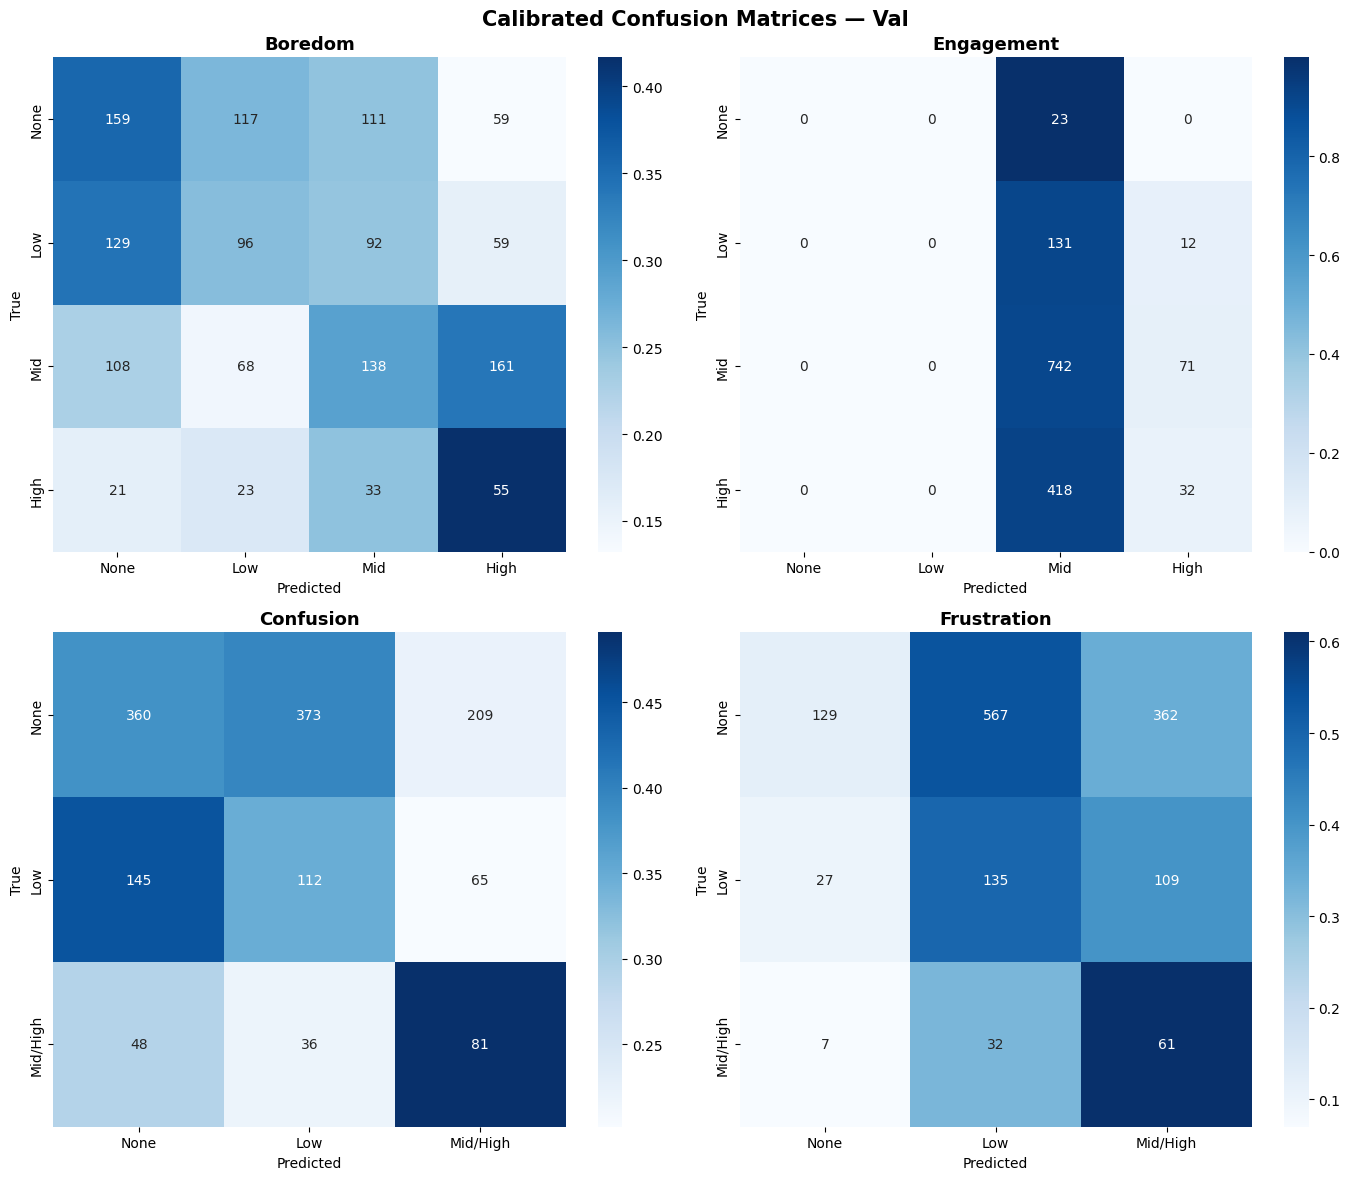

In [21]:
def evaluate(model, gen, thresholds, split='Val'):
    probs, true_labels = collect_probs(model, gen)
    raw_preds          = {col: np.argmax(probs[col], axis=1) for col in TASK_CONFIG}
    cal_preds          = predict_with_thresholds(probs, thresholds)
 
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for ax, col in zip(axes.flatten(), TASK_CONFIG):
        cm      = confusion_matrix(true_labels[col], cal_preds[col])
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=LABEL_NAMES[col], yticklabels=LABEL_NAMES[col])
        ax.set_title(col.replace('_lbl', '').capitalize(),
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
 
        print(f"\n{'='*50}")
        print(f"{col}  — RAW argmax")
        print(classification_report(true_labels[col], raw_preds[col],
                                     target_names=LABEL_NAMES[col], zero_division=0))
        print(f"{col}  — CALIBRATED thresholds")
        print(classification_report(true_labels[col], cal_preds[col],
                                     target_names=LABEL_NAMES[col], zero_division=0))
 
    plt.suptitle(f'Calibrated Confusion Matrices — {split}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'eval_v3_{split.lower()}.png', dpi=150)
    plt.show()
 
 
evaluate(model, val_gen, thresholds, split='Val')

In [23]:
with open('thresholds_v3.json') as f:
    _raw_t = json.load(f)
THRESHOLDS = {k: np.array(v) for k, v in _raw_t.items()}
 
# Rolling frame buffer — shared across calls for webcam/video streaming
_frame_buffer = deque(maxlen=SEQ_LEN)
 
 
def predict_frame(model, frame_bgr, thresholds=THRESHOLDS):

    global _frame_buffer
 
    face, bbox = detect_face(frame_bgr)
    face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)  # keep uint8
    _frame_buffer.append(face)
 
    if len(_frame_buffer) < SEQ_LEN:
        return None, bbox   # still buffering
 
    clip  = np.stack(_frame_buffer)[np.newaxis]   # (1, SEQ_LEN, H, W, 3)
    preds = model.predict(clip, verbose=0)
 
    result = {}
    for col in TASK_CONFIG:
        emotion = col.replace('_lbl', '')
        probs   = preds[col][0]       # (n_cls,)
        t       = thresholds[col]     # (n_cls,)
 
        # Calibrated threshold selection
        masked = np.where(probs >= t, probs, -1.0)
        cls    = int(np.argmax(masked)) if masked.max() >= 0 else int(np.argmax(probs))
 
        result[emotion] = {
            'class':      cls,
            'label':      LABEL_MAPS[emotion][cls],
            'confidence': round(float(probs[cls]), 3),
            'probs':      [round(float(p), 3) for p in probs],
        }
 
    result['engagement']['color'] = ENGAGEMENT_COLOR[result['engagement']['class']]
 
    alert = None
    if result['frustration']['class'] >= 2:
        alert = 'Student appears frustrated'
    elif result['confusion']['class'] >= 2:
        alert = 'Student appears confused'
    elif result['boredom']['class'] >= 2 and result['engagement']['class'] <= 1:
        alert = 'Student appears disengaged'
 
    dominant_key       = max(['boredom','engagement','confusion','frustration'],
                             key=lambda k: result[k]['confidence'])
    result['dominant'] = result[dominant_key]['label']
    result['alert']    = alert
    return result, bbox
 
 
def reset_frame_buffer():

    global _frame_buffer
    _frame_buffer = deque(maxlen=SEQ_LEN)
 
 
print("predict_frame with calibrated thresholds ready.")
 

predict_frame with calibrated thresholds ready.


In [25]:
model.save('EngageTrack_v3_final.keras')
print("Model saved: EngageTrack_v3_final.keras")

Model saved: EngageTrack_v3_final.keras
